In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import os
import importlib
import modules.optics as op
from modules.noise import gauss_noise, poisson_noise, salt_pepper_noise, mix_noise

<Figure size 640x480 with 0 Axes>

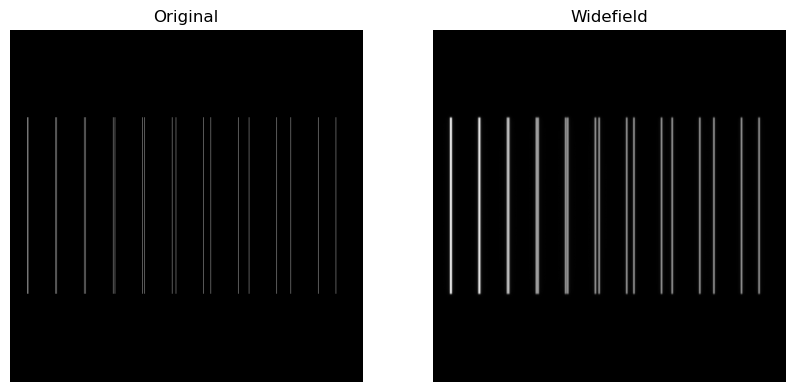

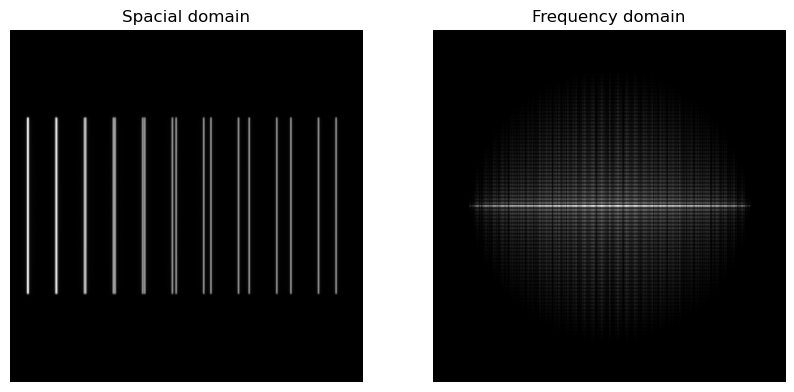

In [6]:
plt.set_cmap('gray')

gt = ski.img_as_float(ski.io.imread('source_images\lines.tif'))

# synthetic_circles = ski.transform.resize(ski.color.rgb2gray(ski.io.imread('source_images\Synthetic_circles.png')[:, :, :3]), (512, 512), anti_aliasing=True)
# print(synthetic_circles.shape, synthetic_circles.min(), synthetic_circles.max())
# synthetic = synthetic_circles

widefield = op.otf_incoherent(gt, NA=1.2, wavelength=60, pixelsize=10)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gt)
ax[0].set_title("Original")
ax[0].axis('off')
ax[1].imshow(widefield)
ax[1].set_title("Widefield")
ax[1].axis('off')
plt.show()

op.display_fourier(widefield)

Noisy PSNR:  30.041739078170064
Noisy SSIM:  0.5915474504815239


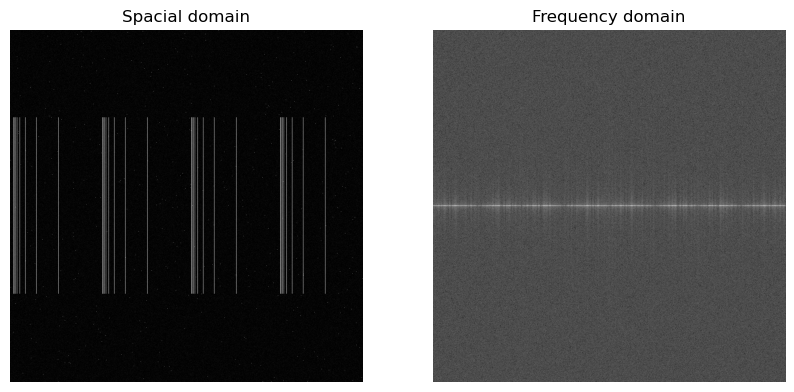

In [4]:
# Add noise to the images
percentage = 0.1
folder_path = 'output_images/simple_circles'

n = 10
mix = np.zeros((n, gt.shape[0], gt.shape[1]))
for i in range(n):
    # gt_gaussian = gauss_noise(gt, percentage)
    # gt_poisson = poisson_noise(gt, percentage)
    # gt_saltpepper = salt_pepper_noise(gt, percentage)
    mix[i] = mix_noise(gt, percentage)

noisy_image = mix

noisy_PSNR = np.zeros(n)
noisy_SSIM = np.zeros(n)

for i in range(n):
    noisy_PSNR[i] = ski.metrics.peak_signal_noise_ratio(gt, noisy_image[i])
    noisy_SSIM[i] = ski.metrics.structural_similarity(gt, noisy_image[i], data_range=1)

print("Noisy PSNR: ", np.mean(noisy_PSNR))
print("Noisy SSIM: ", np.mean(noisy_SSIM))

op.display_fourier(noisy_image[0])

Wiener PSNR:  23.22406990050836
Wiener SSIM:  0.7793858830615978


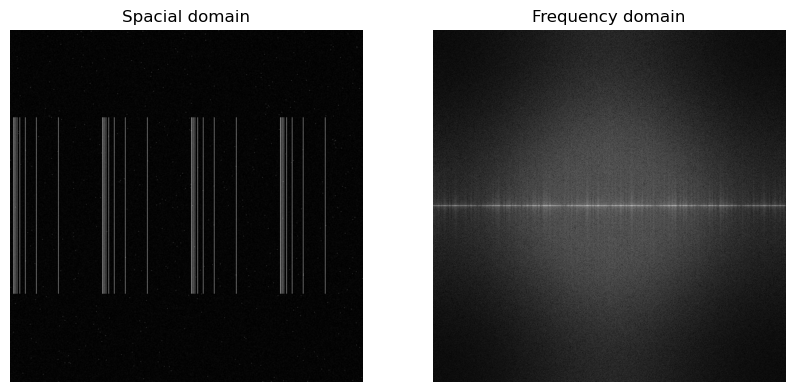

In [ ]:
# Wiener filter
psf = op.gaussian_psf(3)
wiener = np.zeros_like(noisy_image)

balance = 0.2 # 1% 0.0001

for i in range(n):
    wiener[i] = ski.restoration.wiener(noisy_image[i], psf, balance)

wiener_PSNR = np.zeros(n)
wiener_SSIM = np.zeros(n)

for i in range(n):
    wiener_PSNR[i] = ski.metrics.peak_signal_noise_ratio(gt, wiener[i])
    wiener_SSIM[i] = ski.metrics.structural_similarity(gt, wiener[i], data_range=1)
    
print("Wiener PSNR: ", np.mean(wiener_PSNR))
print("Wiener SSIM: ", np.mean(wiener_SSIM))

op.display_fourier(wiener[0])

rl PSNR:  27.87840332054971
rl SSIM:  0.7182235058148457


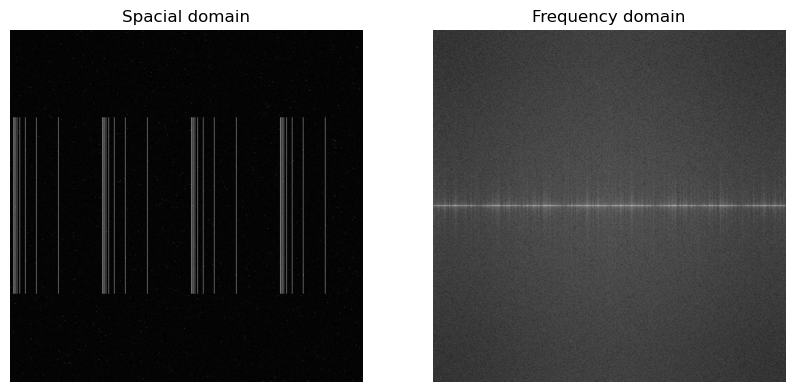

In [11]:
# RL filter
psf = op.gaussian_psf(3)
rl = np.zeros_like(noisy_image)

for i in range(n):
    rl[i] = ski.restoration.richardson_lucy(noisy_image[i], psf, num_iter=1)

rl_PSNR = np.zeros(n)
rl_SSIM = np.zeros(n)

for i in range(n):
    rl_PSNR[i] = ski.metrics.peak_signal_noise_ratio(gt, rl[i])
    rl_SSIM[i] = ski.metrics.structural_similarity(gt, rl[i], data_range=1)
    
print("rl PSNR: ", np.mean(rl_PSNR))
print("rl SSIM: ", np.mean(rl_SSIM))

op.display_fourier(rl[0])